---

In [892]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Task 1: Familiarize Yourself with the Dataset

There are two main subtasks:  
1. Load the four data files that are part of this dataset.  
2. Explore each dataset and define the data types of each column. Describe the contents of each column, including the nature of the data values. Follow a similar approach as demonstrated in the lecture and tutorial. Discuss the shape of the data, value ranges, and possible categories. Convert any data into a more appropriate format if needed.  

Add as many code and markdown cells as necessary below. Typically, you should perform one type of investigation per code cell with output, and then comment on the results in a markdown cell below it.  

After completing the analysis, write a concise summary in the **Task 1: summary report** cell at the end. The final report should succinctly summarize the main characteristics of each data file, how they relate to each other, and any notable features.


In [893]:
# load 4 datasets

sessions = pd.read_csv("data/sessions.csv")
streamers = pd.read_csv("data/streamers.csv")
viewers = pd.read_csv("data/viewers.csv")
streams = pd.read_csv("data/streams.csv")


### Sessions

In [894]:
sessions.head()

,session_id,viewer_id,streamer_id,stream_id,started_at,ended_at,duration_mins,chat_messages_sent,bits_cheered,followed_during,subscribed_during
0,SES000001,VWR00938,STR0055,SM00860,2024-01-18 19:16:00,2024-01-18 20:28:00,72,0,0,False,False
1,SES000002,VWR00804,STR0034,SM00542,2024-01-04 17:11:00,2024-01-04 19:41:00,150,11,0,False,False
2,SES000003,VWR00704,STR0008,SM00124,2024-02-15 15:11:00,2024-02-15 16:53:00,102,5,0,False,False
3,SES000004,VWR00926,STR0024,SM00373,2024-01-18 19:59:00,2024-01-18 20:56:00,57,3,9663,False,False
4,SES000005,VWR00883,STR0008,SM00120,2024-03-19 20:08:00,2024-03-19 20:22:00,14,7,0,False,False


In [895]:
sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22825 entries, 0 to 22824
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   session_id          22825 non-null  object
 1   viewer_id           22825 non-null  object
 2   streamer_id         22765 non-null  object
 3   stream_id           22825 non-null  object
 4   started_at          22825 non-null  object
 5   ended_at            22825 non-null  object
 6   duration_mins       22825 non-null  int64 
 7   chat_messages_sent  22825 non-null  int64 
 8   bits_cheered        22825 non-null  int64 
 9   followed_during     22825 non-null  bool  
 10  subscribed_during   22825 non-null  bool  
dtypes: bool(2), int64(3), object(6)
memory usage: 1.6+ MB


In [896]:
sessions.describe()

,duration_mins,chat_messages_sent,bits_cheered
count,22825.000000,22825.000000,22825.000000
mean,59.051303,6.442629,398.425323
std,60.383979,46.576309,1571.528658
min,0.000000,0.000000,0.000000
25%,15.000000,0.000000,0.000000
50%,39.000000,1.000000,0.000000
75%,83.000000,5.000000,0.000000
max,443.000000,1987.000000,10000.000000


The sessions dataset contains individual viewer sessions. Each row has foreign key viewer_id, streamer_id, and stream_id. streamer_id appears to contain missing values

 2   streamer_id         22765 non-null  object

Started_at and ended at should be converted from string type. Duration ranges from 0-443 min. Chat messages sent has a highly skewed distribution. Bits cheered has a large majority of 0 values.


### Streamers

In [897]:
streamers.head()

,streamer_id,streamer_name,category,language,partner_status,total_followers,avg_concurrent_viewers
0,STR0001,xQc,Just Chatting,English,True,11500000,138706
1,STR0002,Pokimane,Just Chatting,English,True,-25551,71660
2,STR0003,HasanAbi,Just Chatting,English,True,2600000,34220
3,STR0004,Amouranth,Just Chatting,English,True,6200000,68607
4,STR0005,Mizkif,Just Chatting,English,True,2100000,6771


In [898]:
streamers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   streamer_id             76 non-null     object
 1   streamer_name           76 non-null     object
 2   category                76 non-null     object
 3   language                68 non-null     object
 4   partner_status          76 non-null     bool  
 5   total_followers         76 non-null     int64 
 6   avg_concurrent_viewers  76 non-null     int64 
dtypes: bool(1), int64(2), object(4)
memory usage: 3.8+ KB


In [899]:
streamers.describe()

,total_followers,avg_concurrent_viewers
count,7.600000e+01,76.000000
mean,3.300886e+06,31227.986842
std,3.793772e+06,38307.223652
min,-4.696400e+04,634.000000
25%,7.800000e+05,6633.250000
50%,2.000000e+06,14762.500000
75%,3.875000e+06,36840.750000
max,1.870000e+07,156401.000000


Consists of a primary key of streamer_id. Language appears to have missing values (68 non nulls). Also appears to somehow have impossible negative values for total_followers (min	-4.696400e+04). Most numerical engagement metrics appear heavily right-skewed, where a small number of streamers have extremely high viewer counts. Streamers also have a primary streaming category - this will be suitable for grouping and comparative analysis.

### Viewers

In [900]:
viewers.head()

,viewer_id,age_group,country,account_age_days,subscription_tier,preferred_category
0,VWR00001,18-24,AR,355,free,IRL
1,VWR00002,25-34,CA,1670,free,Creative
2,VWR00003,35-44,US,1108,free,Just Chatting
3,VWR00004,45+,NaN,822,tier1,FPS
4,VWR00005,25-34,DE,2226,free,Just Chatting


In [901]:
viewers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   viewer_id           1000 non-null   object
 1   age_group           1000 non-null   object
 2   country             920 non-null    object
 3   account_age_days    1000 non-null   int64 
 4   subscription_tier   1000 non-null   object
 5   preferred_category  1000 non-null   object
dtypes: int64(1), object(5)
memory usage: 47.0+ KB


In [902]:
viewers.describe()

,account_age_days
count,1000.000000
mean,1881.119000
std,1036.144656
min,33.000000
25%,984.500000
50%,1966.500000
75%,2761.250000
max,3645.000000


1000 x 6 dataset. Country contains missing values (920 non-null values of 1000), suggesting incomplete demographic info. account_age_days ranges from 33 to 3645 days, suggesting a mix of new and long-term accounts. subscription_tier consist of string type categories - this can potentially be grouped and used for comparative analysis later on. preferred_category should hopefully match with the streamer categories. Most viewer columns are categorical or string-based except for the account age.

### Streams

In [903]:
streams.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1199 entries, 0 to 1198
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   stream_id            1199 non-null   object 
 1   streamer_id          1199 non-null   object 
 2   started_at           1199 non-null   object 
 3   ended_at             1199 non-null   object 
 4   stream_duration_hrs  1199 non-null   float64
 5   category             1149 non-null   object 
 6   peak_viewers         1119 non-null   float64
 7   title_has_hype_word  1199 non-null   bool   
 8   was_raid             1199 non-null   bool   
dtypes: bool(2), float64(2), object(5)
memory usage: 68.0+ KB


In [904]:
streams.head()

,stream_id,streamer_id,started_at,ended_at,stream_duration_hrs,category,peak_viewers,title_has_hype_word,was_raid
0,SM00001,STR0001,2024-02-14 18:00:00,2024-02-14 21:00:00,3.0,Just Chatting,108989.0,False,True
1,SM00002,STR0001,2024-01-28 18:00:00,2024-01-28 21:00:00,3.0,Just Chatting,51635.0,True,False
2,SM00003,STR0001,2024-01-31 09:00:00,2024-01-31 16:00:00,7.0,Just Chatting,212127.0,False,False
3,SM00004,STR0001,2024-03-03 14:00:00,2024-03-03 21:00:00,7.0,Just Chatting,186745.0,False,True
4,SM00005,STR0001,2024-01-24 18:00:00,2024-01-24 21:00:00,3.0,Just Chatting,87723.0,False,True


In [905]:
streams.describe()

,stream_duration_hrs,peak_viewers
count,1199.000000,1119.000000
mean,4.625104,38375.658624
std,7.995028,50377.085406
min,1.500000,-50.000000
25%,2.500000,7598.500000
50%,3.000000,20224.000000
75%,5.000000,47941.000000
max,96.000000,370165.000000


Same as before, but category appears to have missing values (1149 of 1199). peak_viewers also somehow goes down to -50, and is also missing values (1119 of 1199). There is also a max stream duration of 96 hours.

### Converting timestamp columns to actual datetime format

Currently, started_at and ended_at columns are object string types, but they should be datetime. This will help in extracting month, day, hours, calculating duration, and detecting invalid timestamps. 

In [906]:
# convert started_at to datetime
sessions["started_at"] = pd.to_datetime(sessions["started_at"])
sessions["ended_at"] = pd.to_datetime(sessions["ended_at"])

streams["started_at"] = pd.to_datetime(streams["started_at"])
streams["ended_at"] = pd.to_datetime(streams["ended_at"])

In [907]:
# datetime columns are now in the correct format
sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22825 entries, 0 to 22824
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   session_id          22825 non-null  object        
 1   viewer_id           22825 non-null  object        
 2   streamer_id         22765 non-null  object        
 3   stream_id           22825 non-null  object        
 4   started_at          22825 non-null  datetime64[ns]
 5   ended_at            22825 non-null  datetime64[ns]
 6   duration_mins       22825 non-null  int64         
 7   chat_messages_sent  22825 non-null  int64         
 8   bits_cheered        22825 non-null  int64         
 9   followed_during     22825 non-null  bool          
 10  subscribed_during   22825 non-null  bool          
dtypes: bool(2), datetime64[ns](2), int64(3), object(4)
memory usage: 1.6+ MB


### Task 1 Summary Report

the four datasets, sessions, streamers, viewers, and streams were loaded and inspected using pandas. Dataset columns, shapes, data types, and summary statistics were inspected. started_at and ended_at timestamp columns were initially stored as strings, and were converted to datetime format.

Exploration also revealed some data quality concerns, consisting of missing values in columns and impossible negative values. There are also potential outliers such as unusually long stream durations.

# Task 2: Data Cleaning, Diagnostics, and Corrections

Identify and resolve issues in the dataset. These can be of different kinds, such as:
- Look for duplicates or implausible values (e.g., users with negative followers, invalid age groups). Thoroughly document your exploration of the data. Decide whether these are outliers or the result of a systemic problem. If the latter, resolve the problem here; if they are outliers, we will address those later.  
- Define at least three heuristics (common-sense rules) to flag unusual entries (e.g., someone watching dozens of streams per day). Discuss whether what you found are errors or artifacts.  

I will repeat the instructions here, but this is expected for each task: each code cell should focus on a specific analysis. You should run the code, and in the markdown below each code cell and its result, provide a detailed interpretation of what you have uncovered in that step. After completing the analyses, summarize the key findings in the indicated summary report cell below.


Summary of diagnostics in task 1:
- streamers: 
- language (68/76)
- total_followers min : -4.696400e+04	
- Viewers:
- country (920/1000)
- Streams:
- category (1149/1199)
- peak_viewers (1119/1199)
- peak_viewers min : -50.000000
- stream_duration_hrs max : 96

In [908]:
datasets = {
    "sessions": sessions,
    "streamers": streamers,
    "viewers": viewers,
    "streams": streams
}

In [909]:
# Duplicates check
for name, df in datasets.items():
    print(name, df.duplicated().sum())

sessions 0
streamers 0
viewers 0
streams 0


### Addressing streamers total_followers min and streams peak_viewers min negative values

In [910]:
# Get from datasets where columns total_followers and peak_viewers is negative
negative_followers = streamers[streamers["total_followers"] < 0]
negative_peak_viewers = streams[streams["peak_viewers"] < 0]

display(negative_followers)
negative_peak_viewers.head()


,streamer_id,streamer_name,category,language,partner_status,total_followers,avg_concurrent_viewers
1,STR0002,Pokimane,Just Chatting,English,True,-25551,71660
6,STR0007,Devin_Nash,Just Chatting,English,True,-45130,5114
7,STR0008,Ibai,Just Chatting,Spanish,True,-46964,156401
12,STR0013,Fuslie,Just Chatting,English,True,-8902,9540
24,STR0025,GeT_RiGhT,FPS,English,True,-36135,10785


,stream_id,streamer_id,started_at,ended_at,stream_duration_hrs,category,peak_viewers,title_has_hype_word,was_raid
30,SM00031,STR0002,2024-02-23 18:00:00,2024-02-23 20:30:00,2.5,Just Chatting,-19.0,False,False
58,SM00059,STR0004,2024-03-22 11:00:00,2024-03-22 16:00:00,5.0,Just Chatting,-41.0,True,False
124,SM00125,STR0008,2024-03-10 14:00:00,2024-03-10 18:00:00,4.0,Just Chatting,-43.0,False,False
145,SM00146,STR0009,2024-03-22 15:00:00,2024-03-22 22:00:00,7.0,Just Chatting,-24.0,True,False
174,SM00175,STR0011,2024-01-06 16:00:00,2024-01-06 21:00:00,5.0,Just Chatting,-23.0,False,False


In [911]:
# convert negative falues to NA
streamers.loc[
    streamers["total_followers"] < 0,
    "total_followers"
] = pd.NA

streams.loc[
    streams["peak_viewers"] < 0,
    "peak_viewers"
] = pd.NA

Several streamers contained negative follower counts. Since these appear to be recording errors rather than a meaningful plausable value, I replaced them with Nan instead of being manually corrected.

### Dataset Missing Values

In [912]:
# iterate through the dictionary of datasets
for name, df in datasets.items():
    # count number of missing values
    missing = df.isna().sum()
    # filter out columns with 0 missing values
    missing = missing[missing > 0]

    print(f"\n{name}")

    if missing.empty:
        print("No missing values")
    else:
        print(missing)


sessions
streamer_id    60
dtype: int64

streamers
language           8
total_followers    5
dtype: int64

viewers
country    80
dtype: int64

streams
category         50
peak_viewers    120
dtype: int64


total_followers and peak_viewers has been dealt with before, so we only need to handle string values here

In [913]:
# fill null values with unknown
streamers["language"] = streamers["language"].fillna("Unknown")
viewers["country"] = viewers["country"].fillna("Unknown")
streams["category"] = streams["category"].fillna("Unknown")

### Checking timestamp consistency

In [914]:
# check for sessions and streams where started_at is somehow greater than ended_at
invalid_session_times = sessions[sessions["ended_at"] < sessions["started_at"]]
invalid_stream_times = streams[streams["ended_at"] < streams["started_at"]]

print("invalid session timestamps:", len(invalid_session_times))
print("invalid stream timestamps:", len(invalid_stream_times))

sessions.shape

invalid session timestamps: 40
invalid stream timestamps: 0


(22825, 11)

In [915]:
sessions = sessions[
    sessions["ended_at"] >= sessions ["started_at"]
]

sessions.shape

(22785, 11)

Since these 40 records had an impossible start and end time, I considered these invalid and impossible to determine which timestamp was corect. As it was only 40 out of 22825, the removal is unlikely to materially affect the overall analysis.

#### add computed duration using ended_at - started_at

In [916]:
# compute duration by comparing ended_at and started_at
sessions["computed_duration_mins"] = (
    sessions["ended_at"] - sessions["started_at"]
).dt.total_seconds() / 60

duration_mismatch = sessions[
    sessions["computed_duration_mins"] != sessions["duration_mins"]
]

print("number of duration mismatches:", len(duration_mismatch))

number of duration mismatches: 30


C:\Users\kylez\AppData\Local\Temp\ipykernel_21740\3015108766.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sessions["computed_duration_mins"] = (


30 rows have been identified as having a different duration_mins as the computed_duration_mins.

In [917]:
duration_mismatch.head()

,session_id,viewer_id,streamer_id,stream_id,started_at,ended_at,duration_mins,chat_messages_sent,bits_cheered,followed_during,subscribed_during,computed_duration_mins
1259,SES001260,VWR00620,STR0011,SM00163,2024-03-02 10:20:00,2024-03-02 11:55:00,4,847,0,False,False,95.0
1457,SES001458,VWR00613,STR0075,SM01186,2024-01-04 18:38:00,2024-01-04 20:13:00,5,877,0,False,True,95.0
2716,SES002717,VWR00763,STR0071,SM01121,2024-02-29 11:21:00,2024-02-29 13:07:00,4,1281,921,False,False,106.0
2963,SES002964,VWR00624,STR0020,SM00308,2024-02-18 20:47:00,2024-02-18 21:48:00,4,1103,3885,False,False,61.0
4568,SES004569,VWR00940,STR0008,SM00120,2024-03-19 20:22:00,2024-03-19 20:58:00,4,1383,0,False,False,36.0


Looking at some of these duration mismatches, the duration_mins tend to be 4 or 5 minutes, whereas the computed time is comparably much higher. Chat counts for each of these sessions is also quite large, so sticking with the original duration_mins would indicate, for example, 847 messages within 4 minutes.

Because the timestamps seem more consistent and produced realistic session lengths relative to chat activity, the timestamp-derived duration will be treated as the ground truth.

### Foreign Key mismatches

In [918]:
# check if id exists as foreign key
missing_viewers = sessions["viewer_id"].isin(viewers["viewer_id"]) == False
missing_streamers = sessions["streamer_id"].isin(streamers["streamer_id"]) == False
missing_streams = sessions["stream_id"].isin(streams["stream_id"]) == False

print("Sessions with viewer_id not in viewers:", missing_viewers.sum())
print("Sessions with streamer_id not in streamers:", missing_streamers.sum())
print("Sessions with stream_id not in streams:", missing_streams.sum())

Sessions with viewer_id not in viewers: 0
Sessions with streamer_id not in streamers: 60
Sessions with stream_id not in streams: 34


#### Using streams table to fill in missing streamer_id in sessions

In [919]:
# create mapping series
stream_id_to_streamer = streams.set_index("stream_id")["streamer_id"]

# fill missing values streamer_id using mapping series
sessions["streamer_id"] = sessions["streamer_id"].fillna(
    sessions["stream_id"].map(stream_id_to_streamer)
)

C:\Users\kylez\AppData\Local\Temp\ipykernel_21740\1515497962.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sessions["streamer_id"] = sessions["streamer_id"].fillna(


In [920]:
# show no longer missing
missing_streamers = sessions["streamer_id"].isin(streamers["streamer_id"]) == False
print("Sessions with streamer_id not in streamers:", missing_streamers.sum())

Sessions with streamer_id not in streamers: 0


#### Invalid Category Checks

In [921]:
print(viewers["age_group"].value_counts(dropna=False))
print(viewers["subscription_tier"].value_counts(dropna=False))
print(viewers["preferred_category"].value_counts(dropna=False))

print(streams["category"].value_counts(dropna=False))

print(streamers["language"].value_counts(dropna=False))

age_group
18-24       334
25-34       289
35-44       134
45+         111
13-17        95
18–24        11
18 to 24     11
25–34         6
35 to 44      4
25 to 34      3
35–44         2
Name: count, dtype: int64
subscription_tier
free          578
tier1         243
tier2         100
tier3          49
premium        10
none            7
TIER1           5
free trial      4
tier4           4
Name: count, dtype: int64
preferred_category
Just Chatting    269
FPS              230
MOBA             161
IRL              120
Creative         117
Sports           103
Name: count, dtype: int64
category
Just Chatting    275
FPS              208
Creative         191
Sports           178
MOBA             170
IRL              127
Unknown           50
Name: count, dtype: int64
language
English       61
Unknown        8
Spanish        5
Korean         1
Portuguese     1
Name: count, dtype: int64


Age group formatting has inconsistencies. Same categories are being represented by 18-24, 18–24, or 18 to 24.

In [922]:
# Standardizing age groups

viewers["age_group"] = viewers["age_group"].replace({
    "18–24": "18-24",
    "18 to 24": "18-24",
    "25–34": "25-34",
    "25 to 34": "25-34",
    "35–44": "35-44",
    "35 to 44": "35-44"
})

In [923]:
print(viewers["age_group"].value_counts(dropna=False))

age_group
18-24    356
25-34    298
35-44    140
45+      111
13-17     95
Name: count, dtype: int64


#### Subscription tier checks

Subscription tier also has inconsistent capitalization: tier1, TIER1

tier4 also doesn't exist, premium, none and free trial is also suspicious

In [924]:
viewers["subscription_tier"] = viewers["subscription_tier"].replace({
    "TIER1": "tier1"
})
print(viewers["subscription_tier"].value_counts(dropna=False))


subscription_tier
free          578
tier1         248
tier2         100
tier3          49
premium        10
none            7
free trial      4
tier4           4
Name: count, dtype: int64


In [925]:
tier4_rows = viewers[
    viewers["subscription_tier"] == "tier4"
]

none_rows = viewers[
    viewers["subscription_tier"] == "none"
]

free_trial_rows = viewers[
    viewers["subscription_tier"] == "free trial"
]

display(tier4_rows)
display(none_rows)
display(free_trial_rows)

,viewer_id,age_group,country,account_age_days,subscription_tier,preferred_category
158,VWR00159,35-44,US,2300,tier4,FPS
596,VWR00597,35-44,RU,2395,tier4,Just Chatting
955,VWR00956,45+,US,647,tier4,IRL
990,VWR00991,18-24,BR,1364,tier4,FPS


,viewer_id,age_group,country,account_age_days,subscription_tier,preferred_category
111,VWR00112,35-44,CA,2243,none,Just Chatting
260,VWR00261,25-34,IT,2549,none,Just Chatting
273,VWR00274,18-24,Unknown,2507,none,MOBA
336,VWR00337,25-34,other,2776,none,IRL
397,VWR00398,18-24,AR,2745,none,FPS
666,VWR00667,25-34,Unknown,494,none,Just Chatting
894,VWR00895,18-24,US,3025,none,FPS


,viewer_id,age_group,country,account_age_days,subscription_tier,preferred_category
24,VWR00025,18-24,MX,2280,free trial,Sports
410,VWR00411,25-34,KR,2634,free trial,MOBA
575,VWR00576,25-34,US,445,free trial,MOBA
707,VWR00708,45+,US,3508,free trial,FPS


In [926]:
viewers.groupby("subscription_tier")["account_age_days"].describe()

,count,mean,std,min,25%,50%,75%,max
subscription_tier,,,,,,,,
free,578.0,1790.884083,1043.334189,64.0,865.50,1812.0,2687.25,3639.0
free trial,4.0,2216.750000,1288.994796,445.0,1821.25,2457.0,2852.50,3508.0
none,7.0,2334.142857,847.722523,494.0,2375.00,2549.0,2760.50,3025.0
premium,10.0,1639.800000,1072.002881,63.0,833.25,1640.0,2510.00,3121.0
tier1,248.0,1997.504032,996.080286,51.0,1219.00,2086.5,2816.50,3633.0
tier2,100.0,2023.780000,1069.963566,33.0,1286.25,2221.5,3006.00,3507.0
tier3,49.0,2039.163265,1024.317503,204.0,1157.00,2057.0,3005.00,3645.0
tier4,4.0,1676.500000,829.160419,647.0,1184.75,1832.0,2323.75,2395.0


subscription tier of none seem to have completely normal account ages, countries, preferred categories. These will be standardized as free

In [927]:
viewers["subscription_tier"] = viewers["subscription_tier"].replace({
    "TIER1": "tier1",
    "none": "free"
})

Since tier4 only in 4 rows, this will only be flagged for now and can be replaced with "unknown" in the future.

### Heuristics

#### 1. Session durations cannot exceed the actual stream duration

In [928]:
# left join to bring stream_duration_hrs from streams into sessions via stream_id
sessions_streams = sessions.merge(
    streams[["stream_id", "stream_duration_hrs"]],
    on="stream_id",
    how="left"
)

#convert duration to minutes
sessions_streams["stream_duration_mins"] = (
    sessions_streams["stream_duration_hrs"] * 60
)

# filter for when viewing session is mathematically impossible  - larger than entire stream 
impossible_sessions = sessions_streams[
    sessions_streams["duration_mins"] >
    sessions_streams["stream_duration_mins"]
]

print("num of impossible sessions ", len(impossible_sessions))



num of impossible sessions  0


There are no sessions where the duration is impossible larger than the source stream's duration

#### 2. Viewer watches an abnormally large amount of streams in one day

In [929]:
# extract the calender date from started_at as the date
sessions["date"] = sessions["started_at"].dt.date

# count number of sessions a unique viewer watched on a specific date
viewer_day_counts = (
    sessions.groupby(["viewer_id", "date"])
    .size()
    .reset_index(name="sessions_watched")
)

thresholds = [1, 2, 3,4,5,6,7,8,9,10]

# print viewer activity distribution for up to 10 streams in a day
for threshold in thresholds:
    count = len(viewer_day_counts[viewer_day_counts["sessions_watched"] > threshold])
    print(f"Viewer-days with >{threshold} sessions: {count}")

Viewer-days with >1 sessions: 4393
Viewer-days with >2 sessions: 1238
Viewer-days with >3 sessions: 369
Viewer-days with >4 sessions: 113
Viewer-days with >5 sessions: 33
Viewer-days with >6 sessions: 15
Viewer-days with >7 sessions: 3
Viewer-days with >8 sessions: 0
Viewer-days with >9 sessions: 0
Viewer-days with >10 sessions: 0


C:\Users\kylez\AppData\Local\Temp\ipykernel_21740\3819115812.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sessions["date"] = sessions["started_at"].dt.date


There are less viewers that have more than 5, 6, and 7 sessions in a day. This behavior appears to be uncommon but not impossible.

#### 3. Zero duration sessions should have no activity

In [930]:
zero_duration_activity = sessions[
    # session duration is zero
    (sessions["duration_mins"] == 0) &
    (
        # user has sent chat
        (sessions["chat_messages_sent"] > 0) |

        # user has cheered
        (sessions["bits_cheered"] > 0) |

        # user followed the streamer
        (sessions["followed_during"] == True) |

        # user subscribed
        (sessions["subscribed_during"] == True)
    )
]

print("Zero-duration sessions with activity:", len(zero_duration_activity))
display(zero_duration_activity.head())

Zero-duration sessions with activity: 35


,session_id,viewer_id,streamer_id,stream_id,started_at,ended_at,duration_mins,chat_messages_sent,bits_cheered,followed_during,subscribed_during,computed_duration_mins,date
110,SES000111,VWR00984,STR0009,SM00143,2024-02-07 13:39:00,2024-02-07 13:39:00,0,2,0,False,False,0.0,2024-02-07
306,SES000307,VWR00520,STR0019,SM00288,2024-01-13 19:45:00,2024-01-13 19:45:00,0,0,4406,False,False,0.0,2024-01-13
416,SES000417,VWR00347,STR0041,SM00659,2024-03-23 15:40:00,2024-03-23 15:40:00,0,1,0,False,False,0.0,2024-03-23
826,SES000827,VWR00771,STR0044,SM00692,2024-02-25 18:50:00,2024-02-25 18:50:00,0,1,0,False,False,0.0,2024-02-25
899,SES000900,VWR00247,STR0061,SM00952,2024-03-14 09:33:00,2024-03-14 09:33:00,0,0,6404,False,False,0.0,2024-03-14


35 sessions were found to have a duration of 0, yet still have activity (e.g. 2 chat messages, 4406 bits cheered). These records likely suggest logging or timestamp errors rather than valid user behavior. Since it's not possible to determine the true session duration, these records can only be flagged for now than automatically corrected.

### Task 2 summary report

Several data quality issues were identified, addressed, and flagged across the four datasets of interest. Missing categorical values were replaced with "Unknown", and missing numeric values were left as Nan to avoid introducing biases. Impossible values such as negative counts were treated as data errors and replaced with Nan. 

Timestamp validation revealed 40 sessions where end time occured before the start time. These records were removed as the correct timestamps could not be determined. Additionally, 30 records had incorrect session durations that did not match the timestamps. The start and end time were treated as the source of truth, and a new computed duration was added.

Categorical variables were also standardized and formatted to be consistent. This included representations of age groups, capitalization, and subscription tiers. To note, the subscription tier of tier4 is still suspicious, as that does not exist in Twitch.

Finally, several heuristics were used to identify unusual records, including: sessions longer that their streams, viewers watching unusually many sessions in a day, and zero duration sessions that still had engagement activity. Of these 3, the third heuristic found 35 zero duration sessions that still had activity (chat, bits, etc).

# Task 3: Descriptive Statistics and Visualizations

- Create summary statistics and visualizations to understand user characteristics  
- Create summary statistics for streams data overall, and summaries by age group, account tire, or peak viewers  
- Visualize the distribution of streams durations, popular categories,   
- Show category-specific information and compare streamers based on categories  

#### Streams

In [931]:
# stream duration vs peak viewers
streams[["stream_duration_hrs", "peak_viewers"]].describe()

,stream_duration_hrs,peak_viewers
count,1199.000000,1079.000000
mean,4.625104,39799.299351
std,7.995028,50747.104110
min,1.500000,57.000000
25%,2.500000,9051.000000
50%,3.000000,21421.000000
75%,5.000000,49005.000000
max,96.000000,370165.000000


streams last an average of 4.6 hrs, although the median duration is only 3hr, suggesting a right skewed distribution caused by a small number of very long streams. Streams can range from 1.5 to 96 hrs.

Peak viewership also has substantial variation. Avg peak audience was approx. 39,799 viewers, while the median was 21421, which suggests a small number of highly popular streams. The platform also has a wide disparity in stream popularity, witha minimum of 57 peak viewers to 370k.

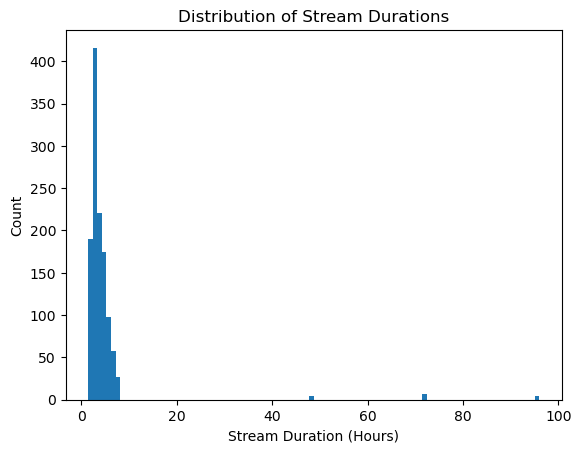

In [932]:
plt.hist(streams["stream_duration_hrs"], bins=100)
plt.xlabel("Stream Duration (Hours)")
plt.ylabel("Count")
plt.title("Distribution of Stream Durations")
plt.show()

Most streams lasted between approximately 1.5 and 8 hrs, with a highest concentration around 2-3. A small number of extremely long streams last around 48, 72, and 96 hours, resulting in a very long right tail. These long streams appear to be outliers and could possibly be 24hr streams or special events (subathons or marathon style streams).

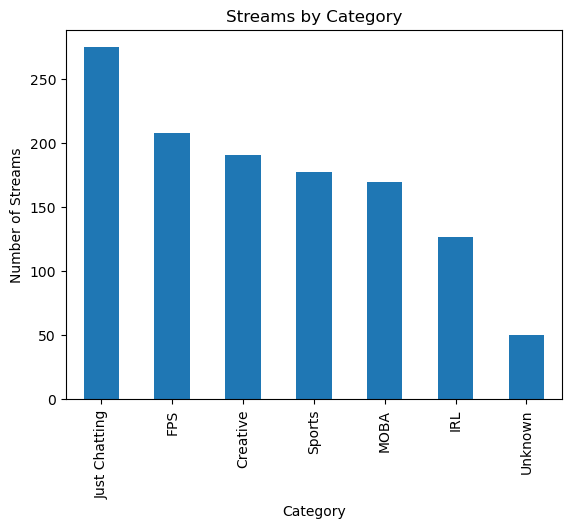

In [933]:
streams["category"].value_counts().plot.bar()
plt.title("Streams by Category")
plt.xlabel("Category")
plt.ylabel("Number of Streams")
plt.show()

Just chatting appears to be the most popular streamed category, followed by FPS and Creative. IRL appears to be noticably less than the categories following up to Just Chatting.

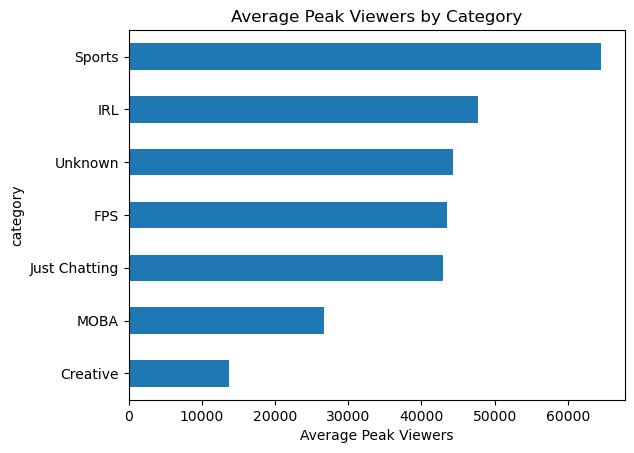

In [934]:
streams.groupby("category")["peak_viewers"] \
    .mean() \
    .sort_values() \
    .plot.barh()

plt.title("Average Peak Viewers by Category")
plt.xlabel("Average Peak Viewers")
plt.show()

Sports has the highest avg peak viewer category, followed by IRL. MOBA has a noticable decrease compared to the other categories. It should be noted that although Just Chatting, FPS, and Creative were the most streamed category as seen previously, their peak viewers rank 4, 5, and 6th in average peak viewer.

This indicates that a category's popular in terms of stream count does not strongly translate to larger audiences per stream.

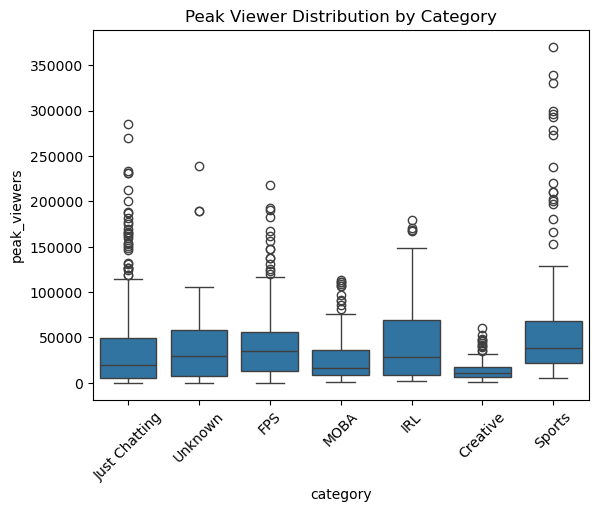

In [935]:
import seaborn as sns

sns.boxplot(
    data=streams,
    x="category",
    y="peak_viewers"
)

plt.title("Peak Viewer Distribution by Category")
plt.xticks(rotation=45)
plt.show()

Sports streams appearr to have the highest median peak viewership, with several extremely high-viewership streams exceeding 300k peak viewers. IRL and FPS also showed relatively strong viewer counts, but Creative has the lowest median peak and also the smallest spread. 

Although Just chatting was shown to have the most stream volume, the median peak is lower than Sports, FPS, and IRL, but still has a relatively large spread.

In [936]:
top_streams = (
    streams
    .sort_values("peak_viewers", ascending=False)
    .head(10)
    .merge(
        streamers[["streamer_id", "streamer_name",]],
        on="streamer_id"
    )
)

display(
    top_streams[
        ["streamer_name", "peak_viewers", "stream_duration_hrs", "title_has_hype_word", "category"]
    ]
)

,streamer_name,peak_viewers,stream_duration_hrs,title_has_hype_word,category
0,IShowSpeed,370165.0,5.0,False,Sports
1,IShowSpeed,338648.0,3.0,False,Sports
2,IShowSpeed,330664.0,6.0,False,Sports
3,IShowSpeed,299413.0,4.0,False,Sports
4,IShowSpeed,296232.0,6.0,False,Sports
5,IShowSpeed,293295.0,4.0,False,Sports
6,Auronplay,285515.0,4.0,False,Just Chatting
7,IShowSpeed,278623.0,4.0,False,Sports
8,IShowSpeed,272708.0,5.0,True,Sports
9,Auronplay,269623.0,3.0,True,Just Chatting


The top 10 streams by peak viewership are dominated by IShowSpeed with 8 streams in the Sports category. Most of the top-performing categories last between 3 to 6 hours, suggesting that exceptionally high viewership is not necessarily associated with unusually long broadcasts. Only 2 of these 10 streams included a hype word in the title, providing little evidence that hype words contribute to peak viewership.

In [937]:
streams.groupby("was_raid")["peak_viewers"] \
    .mean()

was_raid
False    38759.191766
True     45953.269231
Name: peak_viewers, dtype: float64

As expected, raids lead to a larger peak viewer amount.

#### Streamers

In [938]:
# get the avg peak viewer of a streamer
streamer_category_stats = (
    streams.groupby("streamer_id")["peak_viewers"]
    .mean()
    .reset_index(name="avg_peak_viewers")
    # bring in streamer names and categories from streamers
    .merge(
        streamers[["streamer_id", "streamer_name", "category"]],
        on="streamer_id"
    )
)

#get top streamer by category
top_by_category = (
    streamer_category_stats
    .sort_values("avg_peak_viewers", ascending=False)
    .groupby("category")
    .head(1)
)

display(top_by_category)

,streamer_id,avg_peak_viewers,streamer_name,category
61,STR0062,210791.526316,IShowSpeed,Sports
8,STR0009,186502.923077,Auronplay,Just Chatting
18,STR0019,130867.100000,Tfue,FPS
41,STR0042,112790.705882,MoistCr1TiKaL,IRL
32,STR0033,76879.705882,Faker,MOBA
51,STR0052,33866.050000,Northernlion,Creative


In [939]:
top3_by_category = (
    streamer_category_stats
    .sort_values(
        ["category", "avg_peak_viewers"],
        ascending=[True, False]
    )
    .groupby("category")
    .head(3)
)

display(top3_by_category)

,streamer_id,avg_peak_viewers,streamer_name,category
51,STR0052,33866.050000,Northernlion,Creative
57,STR0058,19962.900000,Vinesauce,Creative
52,STR0053,16951.076923,RTGame,Creative
18,STR0019,130867.100000,Tfue,FPS
17,STR0018,112029.333333,shroud,FPS
20,STR0021,72938.000000,TimTheTatman,FPS
41,STR0042,112790.705882,MoistCr1TiKaL,IRL
43,STR0044,104135.588235,Sodapoppin,IRL
40,STR0041,50945.437500,Ludwig,IRL
8,STR0009,186502.923077,Auronplay,Just Chatting


The gap between first and third place in Sports (210,792 vs. 64,949 viewers) is much larger than in categories such as IRL or FPS, indicating that viewership within Sports is heavily concentrated among a small number of dominant creators. IRL also shares this.

#### Viewers

In [940]:
viewers.groupby("age_group")["account_age_days"].describe()

,count,mean,std,min,25%,50%,75%,max
age_group,,,,,,,,
13-17,95.0,1845.442105,981.278657,254.0,1056.00,1875.0,2589.50,3636.0
18-24,356.0,1860.724719,1042.653193,51.0,901.00,1990.0,2746.75,3633.0
25-34,298.0,1852.580537,1023.412149,66.0,971.75,1949.5,2726.75,3639.0
35-44,140.0,1861.171429,1007.691785,40.0,1171.75,1895.0,2589.25,3633.0
45+,111.0,2078.837838,1123.939327,33.0,1088.50,2424.0,3005.00,3645.0


Despite differences in user age, the average account age remains similar for users. The 45+ group was the only category that shows a noticably higher average account age.

In [941]:
viewers.groupby("subscription_tier")["account_age_days"].describe()

,count,mean,std,min,25%,50%,75%,max
subscription_tier,,,,,,,,
free,585.0,1797.384615,1042.294103,64.0,867.00,1835.0,2690.00,3639.0
free trial,4.0,2216.750000,1288.994796,445.0,1821.25,2457.0,2852.50,3508.0
premium,10.0,1639.800000,1072.002881,63.0,833.25,1640.0,2510.00,3121.0
tier1,248.0,1997.504032,996.080286,51.0,1219.00,2086.5,2816.50,3633.0
tier2,100.0,2023.780000,1069.963566,33.0,1286.25,2221.5,3006.00,3507.0
tier3,49.0,2039.163265,1024.317503,204.0,1157.00,2057.0,3005.00,3645.0
tier4,4.0,1676.500000,829.160419,647.0,1184.75,1832.0,2323.75,2395.0


Account age generally increased with subscription level. Free users had the youngest accounts on average (1,797 days), while paid subscribers in tiers 1-3 had older accounts averaging approximately 2,000 days. 
Tier 3 subscribers had the highest average account age at 2,039 days. This suggests that long-term users may be more likely to purchase subscriptions. However, the differences between subscription tiers were relatively modest, and the large standard deviations indicate considerable variation within each group. 

The free trial, premium, and tier4 categories are still suspicious, contained very few users, and should be interpreted cautiously due to their small sample sizes.

In [942]:
sessions_viewers = sessions.merge( viewers[["viewer_id", "age_group"]], on="viewer_id" )

sessions_viewers.groupby("age_group")["duration_mins"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std",
    min="min",
    max="max"
).sort_values("mean")

,count,mean,median,std,min,max
age_group,,,,,,
45+,2816,58.693892,38.0,61.132480,0,423
25-34,6741,58.755229,39.0,59.734124,0,436
13-17,2098,58.824595,39.0,59.804703,0,414
18-24,7980,59.062531,39.0,60.715733,0,443
35-44,3150,60.108254,39.0,60.585804,0,392


As the standard deviations appear nearly identical, age appears to have no significant influence on how long a viewers watch streams.

In [943]:
sessions_viewers = sessions.merge(
    viewers[["viewer_id", "subscription_tier"]],
    on="viewer_id"
)

sessions_viewers.groupby("subscription_tier").agg(
    avg_duration=("duration_mins", "mean"),
    avg_chat_messages=("chat_messages_sent", "mean"),
    avg_bits_cheered=("bits_cheered", "mean")
).sort_values("avg_duration", ascending=False)

,avg_duration,avg_chat_messages,avg_bits_cheered
subscription_tier,,,
tier4,62.437037,3.518519,325.659259
free trial,60.716667,3.466667,478.066667
tier3,60.646701,10.483507,422.507812
tier1,60.213559,6.944514,392.203568
free,58.580557,5.259063,402.971910
tier2,58.443747,11.140512,370.609367
premium,51.024540,3.417178,417.067485


Tier 2 and Tier 3 subscribers sent the most chat messages on average, with over 10 messages per session compared to approximately 5 messages for free users. 

Average bits cheered were relatively similar across tiers, ranging from roughly 370 to 478 bits per session. 

The free trial, premium, and tier4 groups contained very few users and should be interpreted cautiously due to their small sample sizes.

### Task 3 Summary report

The analysis showed that stream durations and peak viewership were both heavily right-skewed, with a small number of extremely long and highly viewed streams.

Viewer demographics had little impact on watch time, as all age groups averaged roughly 59–60 minutes per session. Subscription tiers also showed similar viewing durations, although higher-tier subscribers generally participated more in chat.

Category analysis revealed that Sports and IRL streams attracted the largest audiences, while Creative streams had the lowest average peak viewership. Stream popularity was highly concentrated among a small number of creators, with IShowSpeed dominating both the Sports category and the highest-viewed streams overall. 

Overall, content category and streamer popularity appeared to have a stronger influence on audience size than viewer demographics.

# Task 4: Dealing with Outliers and Missing Values

- Are there any missing values or outliers in the original data? Perform the analysis and report your findings.  
- Are there any outliers or missing values in the derived data? Perform the analysis and report your findings.  
- If there are no outliers or missing values, introduce 3–5% of missing values in a selected column and 1–2% of outliers in another column.  
- Experiment with two strategies for imputing missing values and two strategies for handling outliers. Show how each strategy affects the characteristics of the data.


#### In task 2, there were the identified missing values:

streams["peak_viewers"]   
streamers["total_followers"]  
  
streams["category"]       
streamers["language"]       
viewers["country"]         

#### Numeric missing values

In this example of imputing missing values, we will be using streams["peak_viewers"]

##### 1. Mean Imputation

In [944]:
# fill missing with mean
peak_mean = streams["peak_viewers"].fillna(
    streams["peak_viewers"].mean()
)

##### 2. Median Imputation

In [945]:
# fill missing with median
peak_median = streams["peak_viewers"].fillna(
    streams["peak_viewers"].median()
)

##### Imputation findings

In [946]:
comparison = pd.DataFrame({
    "Original": streams["peak_viewers"].describe(),
    "Mean Imputed": peak_mean.describe(),
    "Median Imputed": peak_median.describe()
})

display(comparison.round(2))

,Original,Mean Imputed,Median Imputed
count,1079.0,1199.00,1199.00
mean,39799.3,39799.30,37959.94
std,50747.1,48138.46,48453.67
min,57.0,57.00,57.00
25%,9051.0,10092.50,10092.50
50%,21421.0,26504.00,21421.00
75%,49005.0,43904.00,43904.00
max,370165.0,370165.00,370165.00


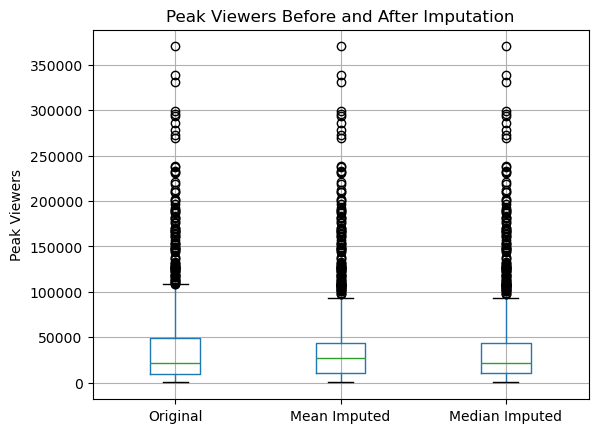

In [947]:
comparison_df = pd.DataFrame({
    "Original": streams["peak_viewers"],
    "Mean Imputed": peak_mean,
    "Median Imputed": peak_median
})

comparison_df.boxplot()

plt.title("Peak Viewers Before and After Imputation")
plt.ylabel("Peak Viewers")
plt.show()

Both imputation strategies increased the number of valid observations from 1079 to 1199 by replacing the missing values.

Mean imputation preserved the original mean, while median imputation reduced the mean to 37960 whil preserving the median. Both methods slightly reduced the standard deviation. 

Since peak viewer distribution is strongly right skewed, median imputation preserved the central tendency or the original distribution and was less influenced by a small number of highly popular streams. Mean imputation introduced larger values in the missing observations, shifting the distribution upwards. In this instance, median imputation was more robust.

#### Numeric Outliers

Previously, we identified obvious outliers in stream_duration_hrs. Typical streams lasted 2-5 hours, while there were outliers at 48, 72, and 96hrs. 

In [948]:
# merge streams and streamers where duration is greater than 24
long_streams = (
    streams[streams["stream_duration_hrs"] >= 24]
    .merge(
        streamers[["streamer_id", "streamer_name", "category"]],
        on="streamer_id"
    )
    .sort_values("stream_duration_hrs", ascending=False)
)

display(
    long_streams[
        [
            "streamer_name",
            "stream_duration_hrs",
            "peak_viewers",
            "title_has_hype_word",
            "was_raid"
        ]
    ]
)

,streamer_name,stream_duration_hrs,peak_viewers,title_has_hype_word,was_raid
9,Caps,96.0,4750.0,False,True
10,Asmongold,96.0,40556.0,False,False
11,Asmongold,96.0,42178.0,False,False
14,Gaules,96.0,33418.0,False,False
1,HasanAbi,72.0,21516.0,False,False
2,shroud,72.0,69221.0,False,False
3,TimTheTatman,72.0,120277.0,False,False
5,s1mple,72.0,37056.0,True,False
7,Symfuhny,72.0,34674.0,False,False
12,Alpharad,72.0,12098.0,False,False


##### 1. remove outliers

In [949]:
Q1 = streams["stream_duration_hrs"].quantile(0.25)
Q3 = streams["stream_duration_hrs"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

duration_removed = streams[
    streams["stream_duration_hrs"].between(lower, upper)
]

##### 2. Cap outliers

In [950]:
# clip using lower and upper values
duration_capped = streams["stream_duration_hrs"].clip(
    lower=lower,
    upper=upper
)

In [951]:
comparison = pd.DataFrame({
    "Original": streams["stream_duration_hrs"].describe(),
    "Removed": duration_removed["stream_duration_hrs"].describe(),
    "Capped": duration_capped.describe()
})

display(comparison.round(2))

,Original,Removed,Capped
count,1199.00,1184.00,1199.00
mean,4.63,3.77,3.83
std,8.00,1.60,1.68
min,1.50,1.50,1.50
25%,2.50,2.50,2.50
50%,3.00,3.00,3.00
75%,5.00,5.00,5.00
max,96.00,8.00,8.75


The original stream duration distribution contained several extremely long streams, resulting in the mean duration of 4.63 hours and a std deviation of 8 hours. Removing the outliers reduced the dataset by 15 observations and lowered the mean to 3.77 hours while reducing the standard deviation to 1.68 hours. Capping the outliers produced a similar effect, lowering the mean to 3.83 hours and the standard deviation to 1.68 hours while preserving all observations.

The median and quartiles remained unchanged under both methods, indicating that the outliers primarily affected the upper tail of the distribution. Since uncapping preserved all observations while limiting the influence of extreme values, it would be preferable when retaining the full dataset is important.

### Task 4 Summary report

Missing values in peak_viewers were handled using mean and median imputation. Because the distribution was heavily right-skewed, median imputation better preserved the original median and was less influenced by extreme values, while mean imputation preserved the overall average.

Outlier analysis was performed on stream_duration_hrs. The longest streams (48–96 hours) appeared to be legitimate marathon broadcasts rather than data errors, but they had a substantial impact on the distribution. Comparing outlier removal and capping showed that both methods significantly reduced the mean and standard deviation of stream duration. Capping preserved all observations while limiting the influence of extreme values, making it a useful alternative to removing data entirely.

# Task 5: Correlation and Behavioral Patterns

- Compute pairwise correlations between user features and the number of check-ins  
- Visualize the results using a correlation matrix (use a coolwarm color scheme and proper scaling)  
- Try Spearman rank correlation and explain when it is more appropriate than Pearson

##### Viewer and platform check-in analysis

In [ ]:
# create a viewer_features dataset grouping sessions for each viewer
# aggregate sessions, total duration, chat, and bits cheered

viewer_features = (
    sessions.groupby("viewer_id")
    .agg(
        num_sessions=("session_id", "count"),
        total_watch_time=("duration_mins", "sum"),
        total_chat=("chat_messages_sent", "sum"),
        total_bits=("bits_cheered", "sum")
    )
    .reset_index()
)

# pull account_age_days from viewers
viewer_features = viewer_features.merge(
    viewers[["viewer_id", "account_age_days"]],
    on="viewer_id"
)

# final correlation dataframe for viewers
correlation_df = viewer_features[
    [
        "num_sessions",
        "total_watch_time",
        "total_chat",
        "total_bits",
        "account_age_days"
    ]
]

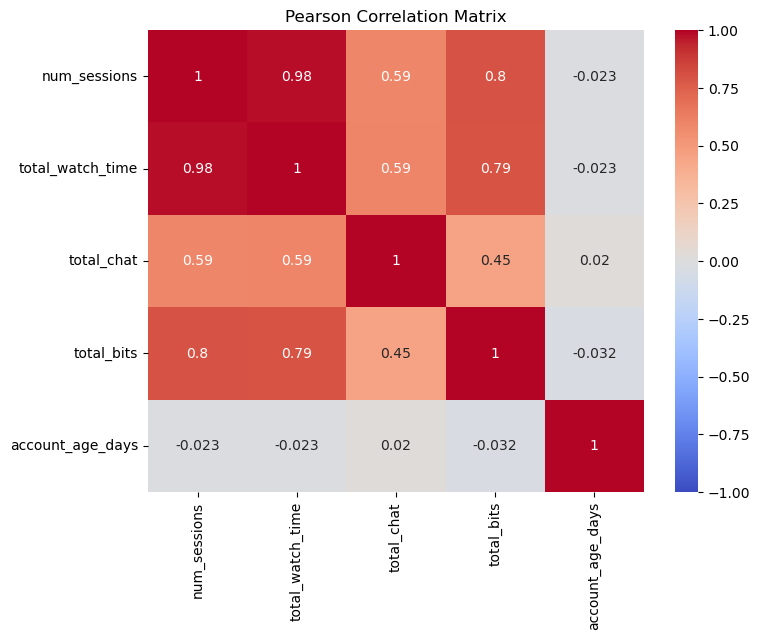

In [961]:
pearson_corr = correlation_df.corr(method="pearson")

plt.figure(figsize=(8, 6))

sns.heatmap(
    pearson_corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Pearson Correlation Matrix")
plt.show()

Total watch time and number of sessions have a near perfect positive correlation of 0.98: Users who watch more sessions naturallY accumulate more total watch time.

Total sessions and total bits have a strong positive correlation of 0.80: Highly active viewers to cheer more bits. Users that engage more are more likely to financially support streamers.

Total watch time and total bits have a strong positive correlation of 0.79: As expected as users withmore sessions also have more watch time, and are more likely to send bits.

Total sessions (and watch time) and total chat have a moderate positive correlation of 0.59: More active viewers tend to send more chat, although the relationship is not as strong as watch time and bits. Some viewers watch passively without chatting.

Total chat and total bits have a moderate positive correlation of 0.45: Chat participation and financial support are related but not strongly. Active chatters tend to cheer more bits.

Non meaningful correlations include: account age

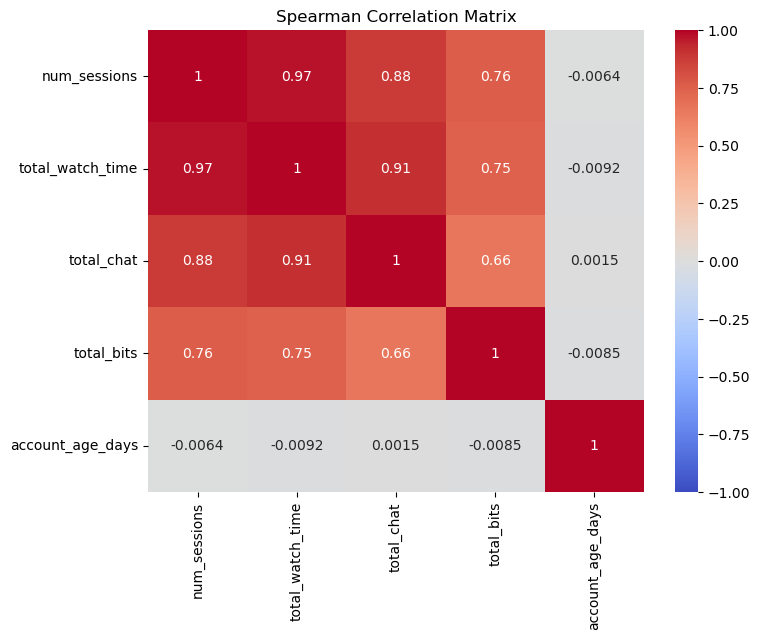

In [962]:
spearman_corr = correlation_df.corr(method="spearman")

plt.figure(figsize=(8, 6))

sns.heatmap(
    spearman_corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Spearman Correlation Matrix")
plt.show()

The greatest difference between Pearson and spearman are:

num_sessions & total_chat 0.58 -> 0.88

total_watch_time & total_chat 0.59 -> 0.91

total_chat & total_bits 0.45 -> 0.66

num_sessions & total_bits 0.80 -> 0.76

The increase of total_watch_time & total_chat, and num_sessions & total_chat suggest the relationship is strongly monotonic but not perfectly linear.

Users who watch more generally send more chat messages, but the increase is not proportional. Pearson only measures linear relationships, while Spearman measures wether the variables consistently increase together regardless of the exact shape of the relationship.

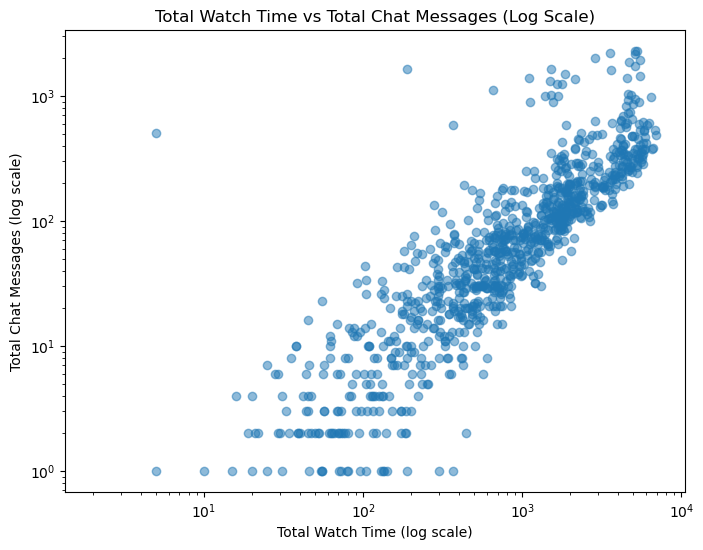

In [976]:
plt.figure(figsize=(8,6))

plt.scatter(
    viewer_features["total_watch_time"],
    viewer_features["total_chat"],
    alpha=0.5
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Total Watch Time (log scale)")
plt.ylabel("Total Chat Messages (log scale)")
plt.title("Total Watch Time vs Total Chat Messages (Log Scale)")
plt.show()

This log-scaled scatter plot reveals a strong positive monotonic relationship between total watch time and total chat messages. Chat activity generally increases along with watch time, but the relationship is not perfectly linear. The clustering of points along an upward trend supports the high Spearman correlation (0.91), indicating that viewers who rank highly in watch time also tend to rank highly in chat activity.

### Task 5 Summary report

Correlation analysis was performed using viewer-level activity metrics, where the number of viewing sessions was treated as an equivalent measure of user check-ins. Strong positive correlations were observed between the number of sessions, total watch time, total chat messages, and total bits cheered, indicating that more active viewers tend to spend more time on the platform, participate more in chat, and provide greater financial support. In contrast, account age showed virtually no correlation with any engagement metric.

Spearman correlations were generally stronger for relationships involving chat activity. Consequently, Spearman is more appropriate in this correlation analysis as num_sessions, total_watch_time, total_chat, total_bits are all highly right-skewed, have extreme users, and aren't normally distributed. Since Spearman converts values to ranks, its more less sensitive to outliers and better for skewed data.

# Task 6: Compare Behavior Across User Segments

- Segment users into 2–3 groups (e.g., by age bracket, account tire)  
- Compare their viewing behavior over time using boxplots or dot plots  
- Identify any outliers in group behavior and investigate them

In [955]:
# task 6 code start here

### Task 6 Summary report

# Task 7: Your Own EDA Questions

Formulate and explore two hypotheses of your own:  
- Propose questions based on curiosity (e.g., “Does a user's variety of categories influence morning vs. evening or session duration?”)  
- Use summary statistics and visualizations to answer each question  
- Briefly discuss what additional data would help you answer the questions more effectively


In [956]:
# task 7 code start here

### Task 7 Summary report

# Task 8: EDA Presentation (Insight Report)

Summarize your findings in a polished format:  
- Create 3–4 slides or a single-page report highlighting your most important insights  
- Include at least 2 charts and interpret them using clear, plain language  
- Apply Tufte’s principles: minimize chartjunk, maximize data-to-ink ratio, and ensure clear labeling  